# Mean-Field Game Model of Limit Order Book Formation
## Polymarket BTC Binary Option — Ask-Side Depth Equilibrium

---

**Abstract.** We derive the equilibrium limit order book (LOB) shape $\mathcal{D}(a)$, which is the aggregate depth posted at each ask price $a$, for the YES side of a Polymarket BTC binary option. The model is a Bertrand mean-field game in which heterogeneous liquidity providers (LPs) choose where to post, and their heterogeneity in discount rates $r \sim G(r)$ generates a continuous depth distribution across ask prices. The central analytical result is that the equilibrium ODE for $\mathcal{D}(a)$ is a **Bernoulli equation of order 3**, exactly solvable in closed form under uniform distributions. We implement the solution, verify it numerically, run comparative statics, and extend to power-law LOB shapes under Pareto $G(r)$.

**Roadmap:**
1. §1–2: Market setup and binary option structure
2. §3–4: LP problem — value function, Bertrand FOC, impulse control
3. §5–6: Equilibrium LOB equation and Bernoulli ODE
4. §7–8: Closed-form solution under uniform $F$ and $G$
5. §9–12: Numerical implementation, verification, and comparative statics
6. §13: Extension to Pareto $G$ (power-law LOB)
7. §14: Connection to price dynamics and informational efficiency
8. §15: Calibration roadmap and next steps

---

# Part I: Market Structure and LP Problem

## §1. Polymarket BTC Digital Option

We consider a binary contract (YES share) on Polymarket that pays at expiration $T$:

$$\text{Payoff}_{YES} = \mathbf{1}\{S_T \ge K\},$$

where $S_T$ is BTC spot at expiration and $K$ is the strike price. Because

$$\text{Payoff}_{NO} = 1 - \text{Payoff}_{YES},$$

there exists a single fundamental price process $p_t \in (0,1)$ representing the market-implied probability of the event. The identity $\text{Payoff}_{NO} = 1 - \text{Payoff}_{YES}$ means that buying NO is economically equivalent to selling YES, so modelling the **YES ask-side book alone** is sufficient to capture the equilibrium liquidity structure.

The key structural feature of Polymarket (relative to traditional LOBs) is that prices live on $[0,1]$ — the contract space of probabilities. This bounded domain creates natural constraints on the LOB that traditional equity models lack.

## §2. Model Primitives

| Symbol | Meaning |
|--------|---------|
| $v \sim F(v)$ on $[0,1]$ | Buyer valuations (beliefs about BTC event) |
| $\alpha$ | Poisson arrival rate of buyers |
| $\phi(a) = \alpha[1-F(a)]$ | Market order flow at ask $a$ |
| $r \sim G(r)$ | LP discount rate distribution (heterogeneous) |
| $c \in (0,1)$ | LP cost basis |
| $d(t)$ | Representative LP's posted depth (state variable) |
| $K$ | Fixed cost per replenishment |
| $\eta$ | Convex carrying cost coefficient: $\gamma(\delta) = \frac{\eta}{2}\delta^2$ |
| $N_{LP}$ | Mass of LPs |
| $\mathcal{D}(a)$ | Aggregate depth at price $a$|

### Buyer Side

Buyers arrive at Poisson rate $\alpha$ with i.i.d. valuations $v \sim F$. A buyer with valuation $v$ purchases if $v \ge a$, so the flow of market buy orders at ask level $a$ is
$$\phi(a) = \alpha[1 - F(a)].$$

### LP Side

A continuum of LPs with mass $N_{LP}$ compete in prices (Bertrand). Each LP $i$ is characterised by a discount rate $r_i \sim G(r)$ drawn from a distribution $G$ on $[r_{\min}, r_{\max}]$. More impatient LPs (higher $r$) demand wider spreads.

Each LP takes the aggregate depth schedule $\mathcal{D}(a)$ as given (mean-field assumption) and optimises:
1. **Own ask price** $a_i$ — Bertrand choice (LP is a price-setter)
2. **Replenishment timing** $\{\tau_k\}$ — impulse control
3. **Replenishment size** $\{\delta_k\}$ — from first-order condition

## §3. Individual LP Problem

### Depth Dynamics

Between replenishments, an LP's posted depth $d(t)$ depletes deterministically as market orders arrive:
$$\dot{d} = -\mu(a) \cdot d, \qquad \mu(a) \equiv \frac{\phi(a)}{\mathcal{D}(a)}.$$

Here $\mu(a)$ is the **fill rate per unit depth** — the rate at which each unit of posted liquidity at ask $a$ gets executed. Since all depth at price $a$ is treated symmetrically, $\mu(a) = \phi(a)/\mathcal{D}(a)$ is the pro-rata execution rate.

### Value Function

The LP's value function satisfies a quasi-variational inequality (QVI). In the **continuation region** (between replenishments), the LP earns $(a-c)$ per unit filled:

$$rV(d) = (a-c)\mu(a)\,d + V'(d)\dot{d} = (a-c)\mu(a)\,d - \mu(a)\,d\,V'(d).$$

This is a linear ODE in $d$ with the exact solution:

$$\boxed{V(d;\, r,\, a) = \frac{(a-c)\,\mu(a)}{r + \mu(a)} \cdot d.}$$

The value is linear in depth $d$ — a key simplification. The coefficient $(a-c)\mu(a)/(r+\mu(a))$ is the **present value of the execution spread per unit depth**, discounted at rate $r + \mu(a)$ (the discount rate $r$ plus the execution hazard rate $\mu$).

## §4. Bertrand FOC and Optimal Replenishment

### Bertrand FOC

Each LP optimises over own ask $a_i$, taking $\mathcal{D}(a)$ as given. The FOC $\partial V/\partial a = 0$ yields:

$$a - c = \frac{[1-F(a)]\,(r + \mu(a))}{r \cdot f(a)}. \tag{Bertrand FOC}$$

This is **increasing in $r$**: more impatient LPs post at higher asks. The economic intuition is immediate — a patient LP (low $r$) is willing to post close to the money and wait for fills; an impatient LP demands a wider spread.

The map $r \mapsto a^*(r)$ is monotone, with inverse:

$$r(a) = \frac{[1-F(a)]\,\mu(a)}{(a-c)f(a) - [1-F(a)]}. \tag{Inverse Map}$$

### Impulse Control: Optimal Replenishment

At each replenishment event, the LP pays a fixed cost $K$ plus convex carrying cost $\frac{\eta}{2}\delta^2$ to restore depth by $\delta$. The intervention operator FOC gives:

$$\delta^*(a) = \frac{(a-c)f(a) - [1-F(a)]}{\eta \cdot f(a)}.$$

**Central simplification:** $\delta^*(a)$ is **independent of $\mathcal{D}(a)$**. The aggregate depth cancels when substituting the equilibrium relation $r(a) = H(a)/\mathcal{D}(a)$ into the replenishment FOC. This decoupling is what makes the model analytically tractable.

---

# Part II: Equilibrium LOB Shape

## §5. The Equilibrium Equation for $\mathcal{D}(a)$

Depth at price level $a$ equals the mass of LPs posting there times the average depth per LP. An LP with discount rate $r(a)$ replenishes to $\delta^*(a)$ and depletes to zero, so its time-average depth is $\delta^*(a)/2$. The mass of LPs in the interval $[a, a+da]$ is $N_{LP} \cdot g(r(a)) \cdot |r'(a)|\,da$ (change of variables from $r$-space to $a$-space). Hence:

$$\mathcal{D}(a) = \frac{N_{LP}\,\delta^*(a)}{2} \cdot g(r(a)) \cdot |r'(a)|. \tag{Equilibrium}$$

Since $r(a) = H(a)/\mathcal{D}(a)$ where
$$H(a) \equiv \frac{[1-F(a)]\,\phi(a)}{(a-c)f(a) - [1-F(a)]},$$

this becomes an **implicit ODE** in $\mathcal{D}(a)$ — $\mathcal{D}$ appears on both sides, and $r'(a)$ involves $\mathcal{D}'$.

## §6. Uniform $F$ and $G$: Reduction to Bernoulli ODE

### Specialisation

Take $v \sim \text{Uniform}[0,1]$ and $r \sim \text{Uniform}[r_{\min}, r_{\max}]$:

$$F(a) = a,\; f(a) = 1,\; 1-F(a) = 1-a, \qquad g(r) = 1/\Delta r,\; \Delta r = r_{\max}-r_{\min}.$$

The building blocks become:

$$\delta^*(a) = \frac{2a - 1 - c}{\eta}, \qquad H(a) = \frac{\alpha(1-a)^2}{2a-1-c}, \qquad a_{\min} = \frac{1+c}{2}.$$

### Deriving the ODE

Under uniform $G$, $g(r) = 1/\Delta r$ is constant. Substituting $r(a) = H(a)/\mathcal{D}(a)$ and differentiating:

$$r'(a) = \frac{H'\mathcal{D} - H\mathcal{D}'}{\mathcal{D}^2}.$$

Inserting into the equilibrium equation and solving for $\mathcal{D}'$:

$$\boxed{\mathcal{D}' = \frac{H'}{H}\,\mathcal{D} \;-\; \frac{2\,\Delta r}{N_{LP}\,\delta^*(a)\,H(a)}\,\mathcal{D}^3.} \tag{Bernoulli ODE}$$

This is a **Bernoulli equation of order 3** in $\mathcal{D}$.

## §7. Exact Solution via the Bernoulli Substitution

### Step 1: Linearise

Set $w(a) = \mathcal{D}(a)^{-2}$, giving $w' = -2\mathcal{D}^{-3}\mathcal{D}'$. The Bernoulli ODE becomes:

$$w' + \frac{2H'(a)}{H(a)}\,w = \frac{4\,\Delta r}{N_{LP}\,\delta^*(a)\,H(a)}.$$

### Step 2: Integrating Factor

The integrating factor for $2H'/H$ is $H(a)^2$. Multiplying through:

$$\frac{d}{da}\bigl[H(a)^2 w(a)\bigr] = \frac{4\,\Delta r\,H(a)}{N_{LP}\,\delta^*(a)}.$$

### Step 3: Integrate with Boundary Condition

At the left edge $a_0$: $r(a_0) = r_{\min}$, so $\mathcal{D}(a_0) = H(a_0)/r_{\min}$ and $H(a_0)^2 w(a_0) = r_{\min}^2$.

Defining the cumulative integral
$$\Phi(a) \equiv \frac{4\,\Delta r}{N_{LP}} \int_{a_0}^{a} \frac{H(s)}{\delta^*(s)}\,ds,$$

we obtain the **closed-form equilibrium LOB shape**:

$$\boxed{\mathcal{D}(a) = \frac{H(a)}{\sqrt{r_{\min}^2 + \Phi(a)}}, \qquad r(a) = \sqrt{r_{\min}^2 + \Phi(a)}.} \tag{$\star$}$$

The book's right edge $a_{\max}$ satisfies $\Phi(a_{\max}) = r_{\max}^2 - r_{\min}^2$.

## §8. Closed-Form Antiderivative

Under uniform $F$, the integrand simplifies to:
$$\frac{H(s)}{\delta^*(s)} = \frac{\alpha\eta(1-s)^2}{(2s-1-c)^2}.$$

Substituting $\sigma = 2s-1-c$ and $\omega = 1-c$:

$$J(s) = \frac{1}{8}\left[-\frac{(1-c)^2}{2s-1-c} - 2(1-c)\ln(2s-1-c) + (2s-1-c)\right]$$

gives $\Phi(a) = \frac{4\alpha\eta\Delta r}{N_{LP}}[J(a) - J(a_0)]$.

The entire solution is **fully explicit** — no numerical quadrature required.

### Book Concentration Phenomenon

Near $a_{\min}$, $H/\delta^* \sim (a-a_{\min})^{-2}$. This strong singularity causes $\Phi$ to grow like $(a-a_{\min})^{-1}$, making $r(a)$ shoot up rapidly. The equilibrium LOB is **concentrated near $a_{\min}$** — patient LPs crowd just above the minimum viable ask. This is a structural prediction of the uniform-uniform model.

---

# Part III: Implementation and Results

In [1]:
import numpy as np
from scipy.optimize import brentq
from scipy.integrate import solve_ivp, trapezoid
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12,
    'axes.labelsize': 14, 'axes.titlesize': 14,
    'legend.fontsize': 11, 'lines.linewidth': 2, 'figure.dpi': 120,
})

## §9. Core Functions

In [2]:
# ============================================================
# Core model functions (uniform F on [0,1])
# ============================================================

def delta_star(a, c, eta):
    """Optimal replenishment: delta*(a) = (2a - 1 - c) / eta."""
    return np.maximum((2*a - 1.0 - c) / eta, 0.0)

def H_func(a, alpha, c):
    """H(a) = alpha*(1-a)^2 / (2a - 1 - c)."""
    sigma = 2*a - 1.0 - c
    return np.where(sigma > 1e-15, alpha * (1.0 - a)**2 / sigma, np.inf)

def H_prime(a, alpha, c):
    """dH/da by quotient rule."""
    sigma = 2*a - 1.0 - c
    num = (1.0 - a)**2
    return alpha * (-2*(1.0-a)*sigma - 2*num) / sigma**2

def J_antideriv(s, c):
    """Antiderivative of (1-s)^2 / (2s-1-c)^2."""
    sigma = 2*s - 1.0 - c
    omega = 1.0 - c
    return (1.0/8.0) * (-omega**2 / sigma - 2*omega*np.log(sigma) + sigma)

def Phi_exact(a, a0, alpha, c, eta, N_LP, Delta_r):
    """Cumulative integral Phi(a) using the closed-form antiderivative."""
    coeff = 4 * alpha * eta * Delta_r / N_LP
    return coeff * (J_antideriv(a, c) - J_antideriv(a0, c))

def D_closedform(a, a0, r_min, alpha, c, eta, N_LP, Delta_r):
    """Closed-form D(a) = H(a) / sqrt(r_min^2 + Phi(a)).  [Equation *]"""
    H = H_func(a, alpha, c)
    Ph = Phi_exact(a, a0, alpha, c, eta, N_LP, Delta_r)
    return H / np.sqrt(r_min**2 + Ph)

def r_closedform(a, a0, r_min, alpha, c, eta, N_LP, Delta_r):
    """r(a) = sqrt(r_min^2 + Phi(a))."""
    Ph = Phi_exact(a, a0, alpha, c, eta, N_LP, Delta_r)
    return np.sqrt(r_min**2 + Ph)

def find_book_boundaries(a_min, r_min, r_max, alpha, c, eta, N_LP, Delta_r, eps=0.005):
    """Find a0 (left edge) and a_max (right edge) of the book."""
    a0 = a_min + eps
    target = r_max**2 - r_min**2
    Phi_at_1 = Phi_exact(0.999, a0, alpha, c, eta, N_LP, Delta_r)
    if Phi_at_1 < target:
        return a0, 0.999
    a_max = brentq(lambda a: Phi_exact(a, a0, alpha, c, eta, N_LP, Delta_r) - target,
                   a0 + 1e-8, 0.999, xtol=1e-12)
    return a0, a_max

def compute_lob(alpha_p, c_p, eta_p, N_LP_p, r_min_p, r_max_p, eps_p=0.005, n_pts=500):
    """Full equilibrium computation for given parameters. Returns dict."""
    Dr = r_max_p - r_min_p
    am = (1 + c_p) / 2
    a0_p, amax_p = find_book_boundaries(am, r_min_p, r_max_p, alpha_p, c_p, eta_p, N_LP_p, Dr, eps_p)
    ag = np.linspace(a0_p + 1e-8, amax_p - 1e-8, n_pts)
    Dv = D_closedform(ag, a0_p, r_min_p, alpha_p, c_p, eta_p, N_LP_p, Dr)
    rv = r_closedform(ag, a0_p, r_min_p, alpha_p, c_p, eta_p, N_LP_p, Dr)
    return {'a': ag, 'D': Dv, 'r': rv, 'delta': delta_star(ag, c_p, eta_p),
            'mu': alpha_p*(1-ag)/Dv, 'a0': a0_p, 'a_max': amax_p, 'a_min': am,
            'total_depth': trapezoid(Dv, ag), 'book_width': amax_p - a0_p}

print('Core functions defined.')

Core functions defined.


## §10. Baseline Equilibrium

In [16]:
# === Baseline Parameters ===
alpha = 10.0       # Buyer arrival rate
c     = 0.30       # LP cost basis
eta   = 5.0        # Convex carrying-cost coefficient
N_LP  = 50.0       # Mass of LPs
r_min = 0.5       # Most patient LP
r_max = 0.5       # Most impatient LP

Delta_r = r_max - r_min
a_min   = (1.0 + c) / 2.0
eps     = 0.005

a0, a_max = find_book_boundaries(a_min, r_min, r_max, alpha, c, eta, N_LP, Delta_r, eps)

print(f'a_min  = (1+c)/2 = {a_min:.4f}')
print(f'a_0    = {a0:.6f}')
print(f'a_max  = {a_max:.6f}')
print(f'Width  = {(a_max-a0)*1e4:.2f} x 10^-4')
print(f'r(a0)  = {r_closedform(a0, a0, r_min, alpha, c, eta, N_LP, Delta_r):.6f}  (r_min={r_min})')
print(f'r(amax)= {r_closedform(a_max, a0, r_min, alpha, c, eta, N_LP, Delta_r):.6f}  (r_max={r_max})')

a_min  = (1+c)/2 = 0.6500
a_0    = 0.655000
a_max  = 0.655000
Width  = 0.00 x 10^-4
r(a0)  = 0.500000  (r_min=0.5)
r(amax)= 0.500000  (r_max=0.5)


C:\Users\filip\AppData\Local\Temp\ipykernel_4292\1272774632.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


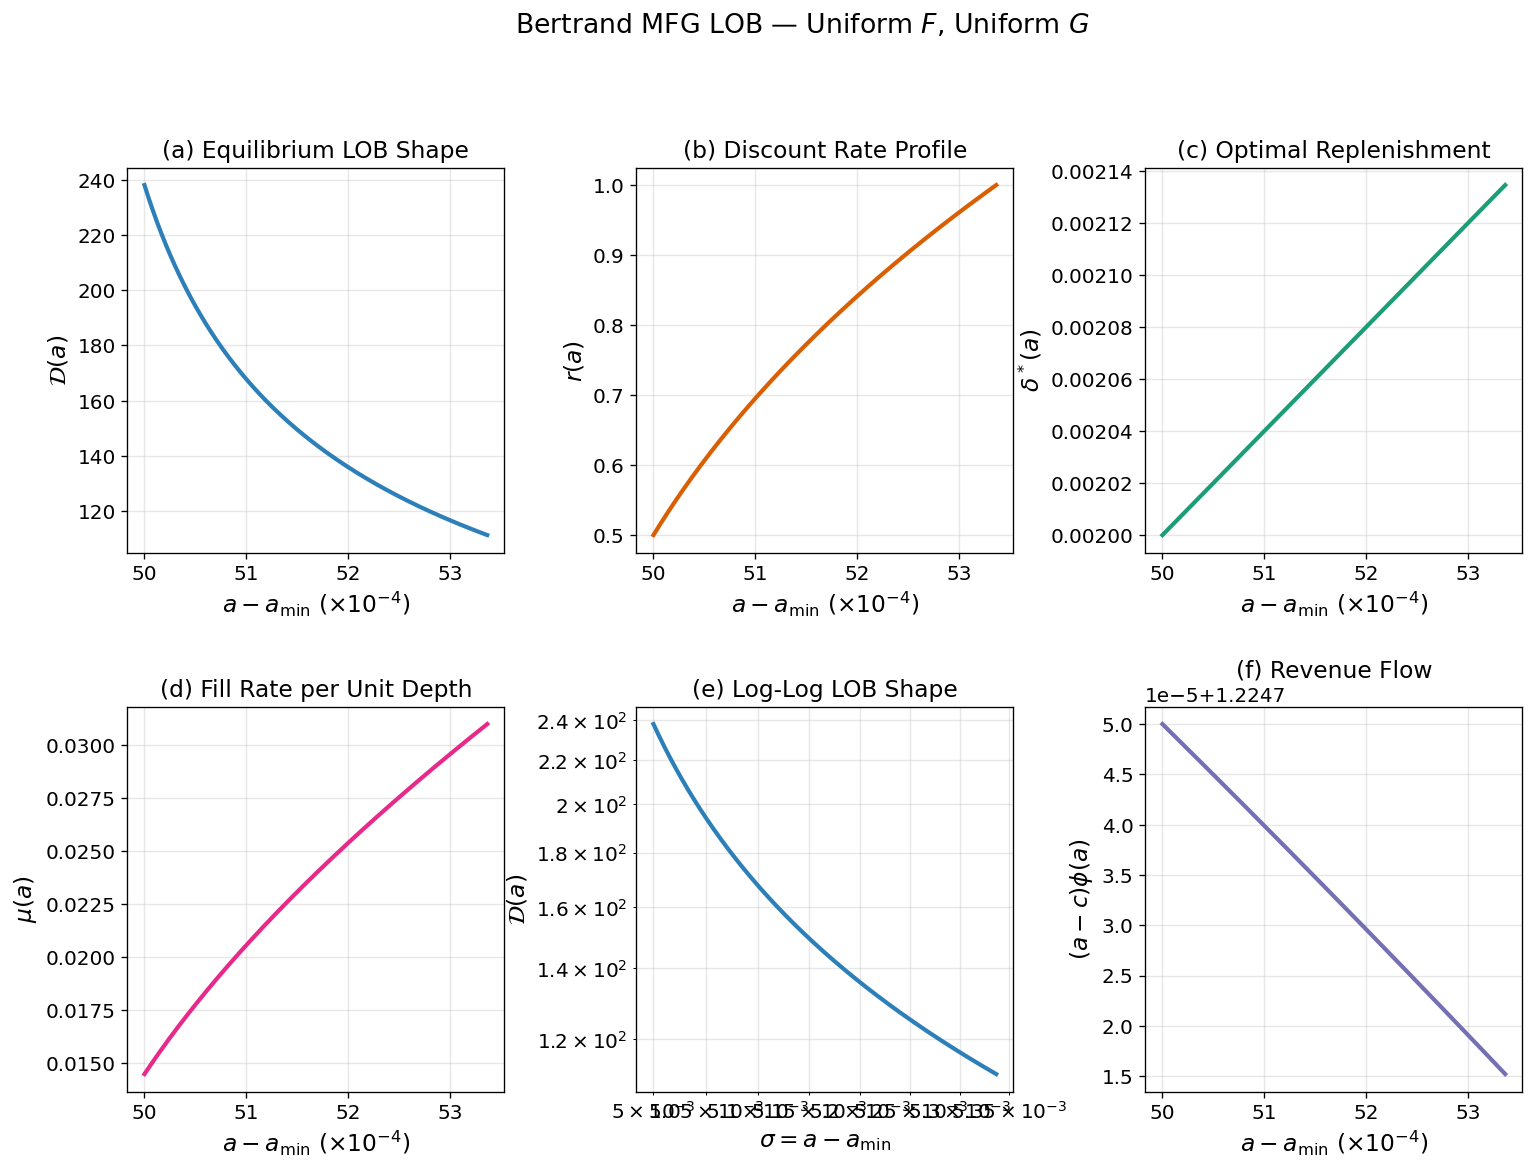


Total depth = 0.0515,  D_max = 238.0


In [15]:
# === Six-panel equilibrium plot ===
a_grid = np.linspace(a0 + 1e-8, a_max - 1e-8, 1000)
D_vals     = D_closedform(a_grid, a0, r_min, alpha, c, eta, N_LP, Delta_r)
r_vals     = r_closedform(a_grid, a0, r_min, alpha, c, eta, N_LP, Delta_r)
delta_vals = delta_star(a_grid, c, eta)
mu_vals    = alpha * (1 - a_grid) / D_vals
phi_vals   = alpha * (1 - a_grid)
sigma_grid = a_grid - a_min

fig = plt.figure(figsize=(15, 10))
gs = GridSpec(2, 3, hspace=0.4, wspace=0.35)

panels = [
    (gs[0,0], sigma_grid*1e4, D_vals, '#2c7fb8', r'$\mathcal{D}(a)$', '(a) Equilibrium LOB Shape'),
    (gs[0,1], sigma_grid*1e4, r_vals, '#d95f02', r'$r(a)$', '(b) Discount Rate Profile'),
    (gs[0,2], sigma_grid*1e4, delta_vals, '#1b9e77', r'$\delta^*(a)$', '(c) Optimal Replenishment'),
    (gs[1,0], sigma_grid*1e4, mu_vals, '#e7298a', r'$\mu(a)$', '(d) Fill Rate per Unit Depth'),
]
for pos, x, y, col, ylab, title in panels:
    ax = fig.add_subplot(pos)
    ax.plot(x, y, color=col, lw=2.5)
    ax.set_xlabel(r'$a - a_{\min}$ ($\times 10^{-4}$)')
    ax.set_ylabel(ylab); ax.set_title(title); ax.grid(True, alpha=0.3)

# Log-log
ax5 = fig.add_subplot(gs[1,1])
ax5.loglog(sigma_grid, D_vals, color='#2c7fb8', lw=2.5)
ax5.set_xlabel(r'$\sigma = a - a_{\min}$'); ax5.set_ylabel(r'$\mathcal{D}(a)$')
ax5.set_title('(e) Log-Log LOB Shape'); ax5.grid(True, alpha=0.3, which='both')

# Revenue
ax6 = fig.add_subplot(gs[1,2])
ax6.plot(sigma_grid*1e4, (a_grid-c)*phi_vals, color='#7570b3', lw=2.5)
ax6.set_xlabel(r'$a - a_{\min}$ ($\times 10^{-4}$)')
ax6.set_ylabel(r'$(a-c)\phi(a)$'); ax6.set_title('(f) Revenue Flow')
ax6.grid(True, alpha=0.3)

fig.suptitle(r'Bertrand MFG LOB — Uniform $F$, Uniform $G$', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

td = trapezoid(D_vals, a_grid)
print(f'\nTotal depth = {td:.4f},  D_max = {np.max(D_vals):.1f}')

## §11. Cross-Validation

We verify (★) by solving the Bernoulli ODE directly with `solve_ivp` (DOP853, tol $= 10^{-12}$).

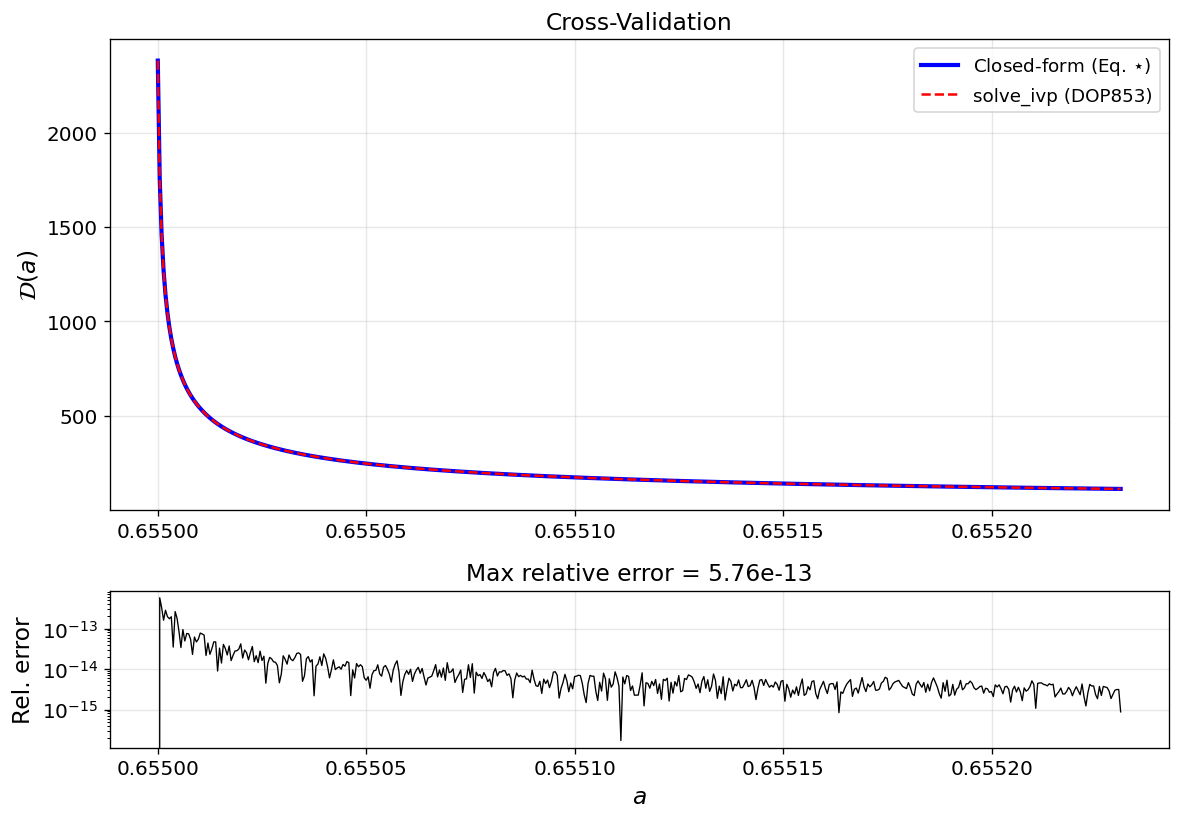

In [5]:
def bernoulli_rhs(a, D_vec):
    D = D_vec[0]
    if D < 1e-15: return [0.0]
    Hv = float(H_func(float(a), alpha, c))
    Hp = float(H_prime(float(a), alpha, c))
    ds = float(delta_star(float(a), c, eta))
    if ds < 1e-15: return [0.0]
    return [(Hp/Hv)*D - (2*Delta_r/(N_LP*ds*Hv))*D**3]

D0 = float(D_closedform(a0, a0, r_min, alpha, c, eta, N_LP, Delta_r))
sol = solve_ivp(bernoulli_rhs, [a0, a_max], [D0], method='DOP853',
                dense_output=True, rtol=1e-12, atol=1e-14,
                max_step=(a_max-a0)/500)

a_num = np.linspace(a0, a_max, 500)
D_num = sol.sol(a_num)[0]
D_cf  = D_closedform(a_num, a0, r_min, alpha, c, eta, N_LP, Delta_r)
rel_err = np.abs(D_num - D_cf) / (np.abs(D_cf) + 1e-20)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), height_ratios=[3, 1])
ax1.plot(a_num, D_cf, 'b-', lw=2.5, label=r'Closed-form (Eq. $\star$)')
ax1.plot(a_num, D_num, 'r--', lw=1.5, label='solve_ivp (DOP853)')
ax1.set_ylabel(r'$\mathcal{D}(a)$'); ax1.set_title('Cross-Validation')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.semilogy(a_num, rel_err, 'k-', lw=0.8)
ax2.set_xlabel('$a$'); ax2.set_ylabel('Rel. error')
ax2.set_title(f'Max relative error = {np.max(rel_err):.2e}')
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## §12. Comparative Statics

N_LP=  20: width=0.90x10^-4, depth=0.0201
N_LP=  50: width=2.31x10^-4, depth=0.0508
N_LP= 100: width=4.84x10^-4, depth=0.1033
N_LP= 200: width=10.75x10^-4, depth=0.2140


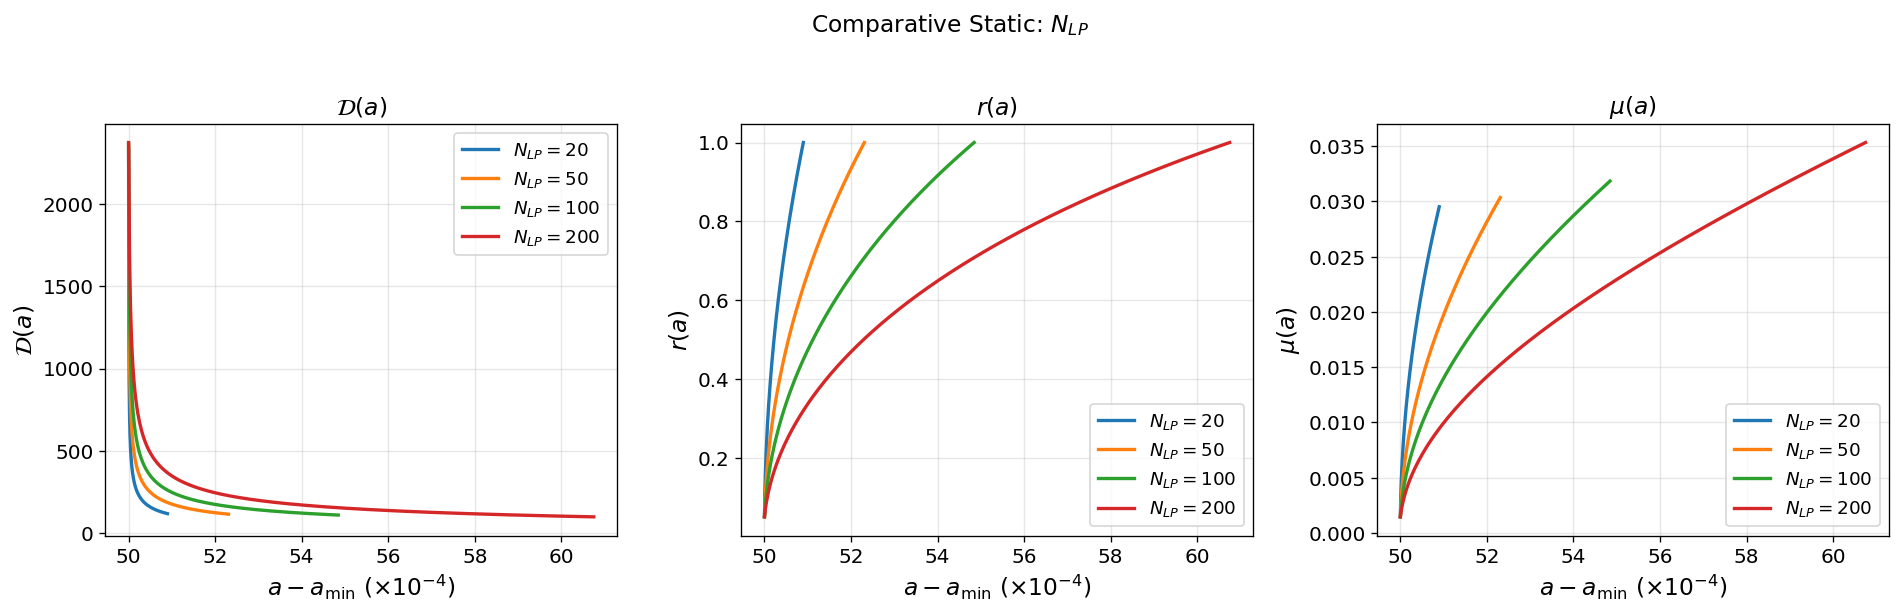

In [6]:
# === CS1: LP Mass ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for N_val in [20, 50, 100, 200]:
    res = compute_lob(alpha, c, eta, N_val, r_min, r_max)
    sig = res['a'] - res['a_min']
    axes[0].plot(sig*1e4, res['D'],  label=f'$N_{{LP}}={N_val}$')
    axes[1].plot(sig*1e4, res['r'],  label=f'$N_{{LP}}={N_val}$')
    axes[2].plot(sig*1e4, res['mu'], label=f'$N_{{LP}}={N_val}$')
    print(f'N_LP={N_val:>4d}: width={res["book_width"]*1e4:.2f}x10^-4, depth={res["total_depth"]:.4f}')

for i, (t, y) in enumerate([
    (r'$\mathcal{D}(a)$', r'$\mathcal{D}(a)$'),
    (r'$r(a)$', r'$r(a)$'), (r'$\mu(a)$', r'$\mu(a)$')]):
    axes[i].set_title(t); axes[i].set_ylabel(y)
    axes[i].set_xlabel(r'$a - a_{\min}$ ($\times 10^{-4}$)')
    axes[i].legend(); axes[i].grid(True, alpha=0.3)
fig.suptitle(r'Comparative Static: $N_{LP}$', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

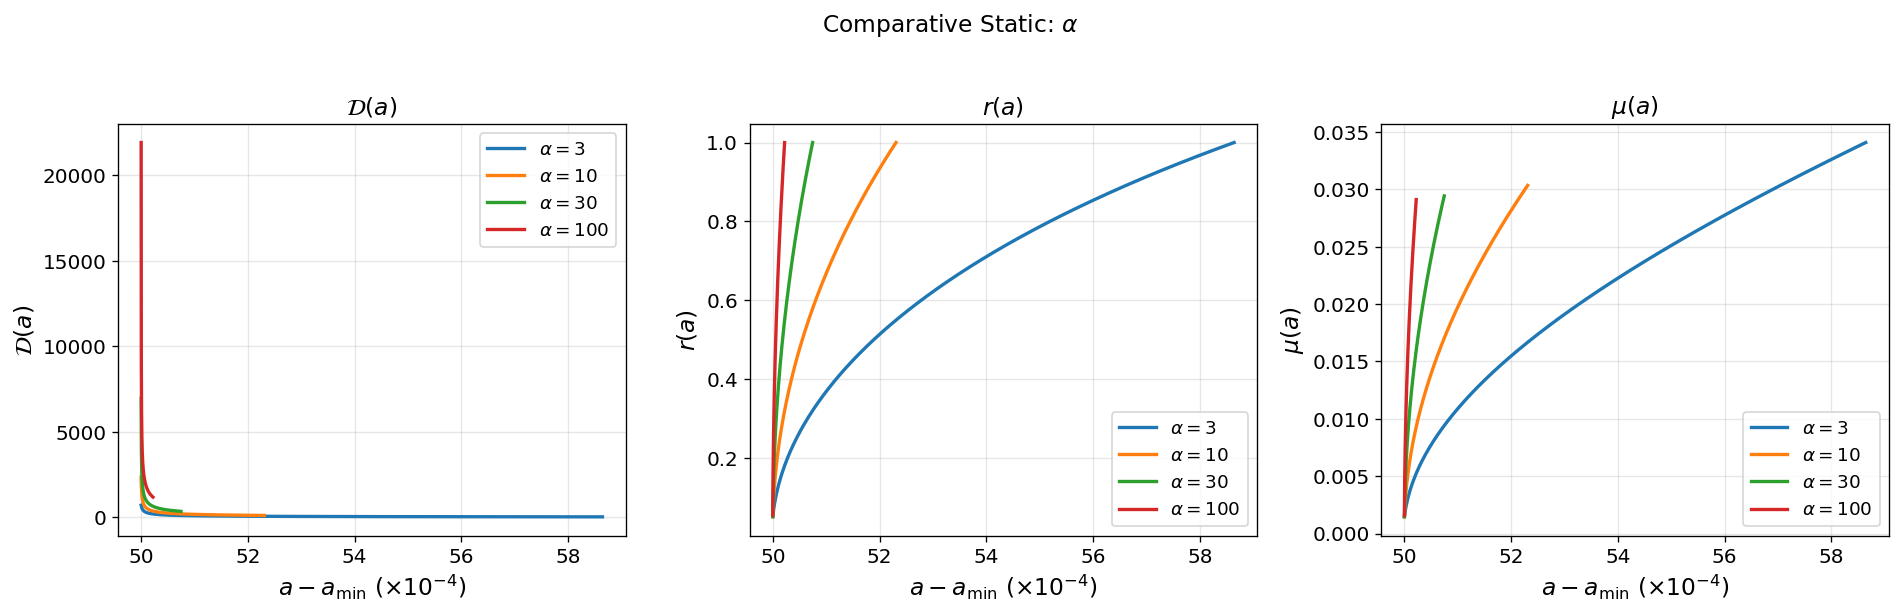

In [7]:
# === CS2: Buyer arrival rate alpha ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for alpha_val in [3, 10, 30, 100]:
    res = compute_lob(alpha_val, c, eta, N_LP, r_min, r_max)
    sig = res['a'] - res['a_min']
    axes[0].plot(sig*1e4, res['D'],  label=rf'$\alpha={alpha_val}$')
    axes[1].plot(sig*1e4, res['r'],  label=rf'$\alpha={alpha_val}$')
    axes[2].plot(sig*1e4, res['mu'], label=rf'$\alpha={alpha_val}$')
for i, (t, y) in enumerate([(r'$\mathcal{D}(a)$', r'$\mathcal{D}(a)$'),
    (r'$r(a)$', r'$r(a)$'), (r'$\mu(a)$', r'$\mu(a)$')]):
    axes[i].set_title(t); axes[i].set_ylabel(y)
    axes[i].set_xlabel(r'$a - a_{\min}$ ($\times 10^{-4}$)')
    axes[i].legend(); axes[i].grid(True, alpha=0.3)
fig.suptitle(r'Comparative Static: $\alpha$', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

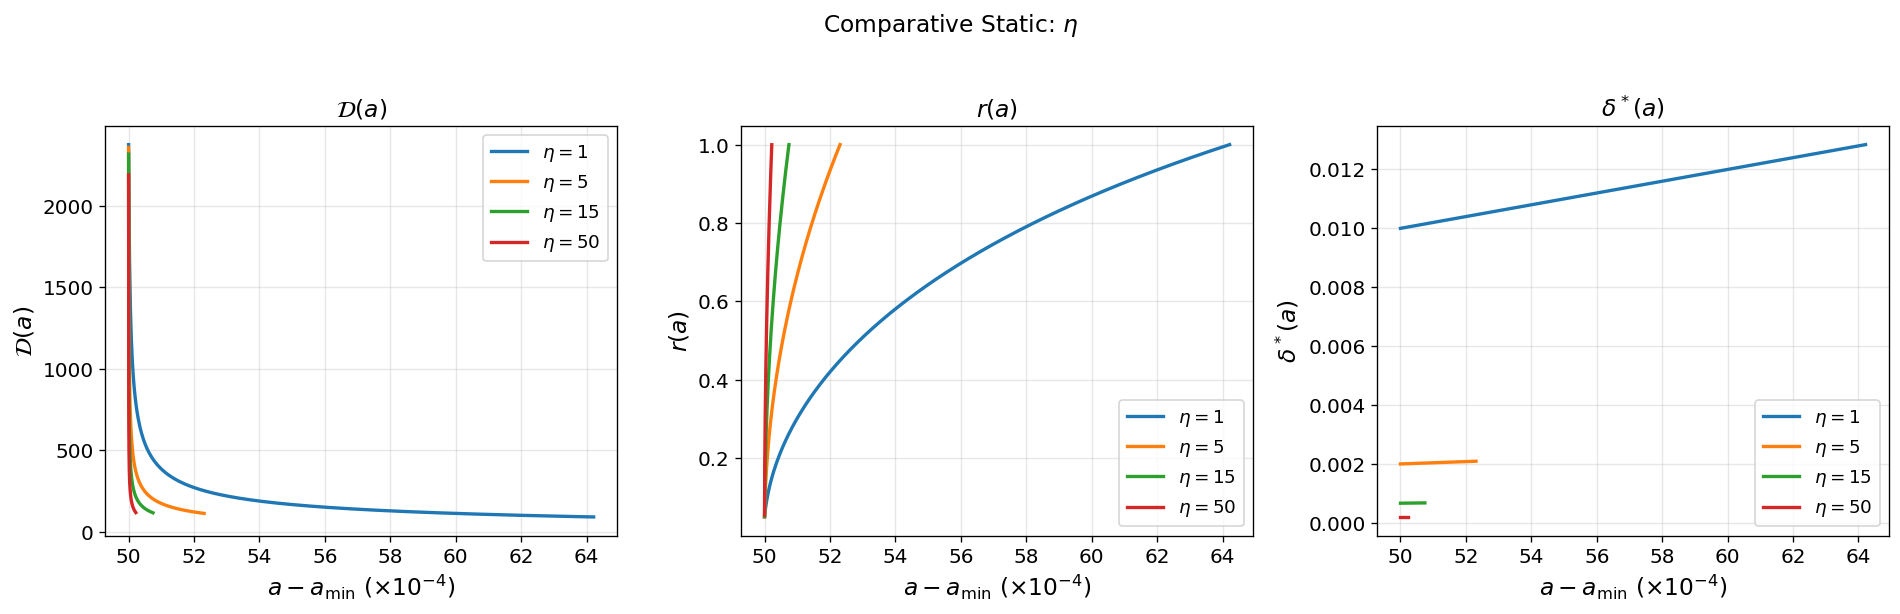

In [8]:
# === CS3: Carrying cost eta ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for eta_val in [1, 5, 15, 50]:
    res = compute_lob(alpha, c, eta_val, N_LP, r_min, r_max)
    sig = res['a'] - res['a_min']
    axes[0].plot(sig*1e4, res['D'],     label=rf'$\eta={eta_val}$')
    axes[1].plot(sig*1e4, res['r'],     label=rf'$\eta={eta_val}$')
    axes[2].plot(sig*1e4, res['delta'], label=rf'$\eta={eta_val}$')
for i, (t, y) in enumerate([(r'$\mathcal{D}(a)$', r'$\mathcal{D}(a)$'),
    (r'$r(a)$', r'$r(a)$'), (r'$\delta^*(a)$', r'$\delta^*(a)$')]):
    axes[i].set_title(t); axes[i].set_ylabel(y)
    axes[i].set_xlabel(r'$a - a_{\min}$ ($\times 10^{-4}$)')
    axes[i].legend(); axes[i].grid(True, alpha=0.3)
fig.suptitle(r'Comparative Static: $\eta$', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

c=0.10: a_min=0.550, width=1.36x10^-4
c=0.30: a_min=0.650, width=2.31x10^-4
c=0.50: a_min=0.750, width=4.80x10^-4
c=0.70: a_min=0.850, width=16.88x10^-4


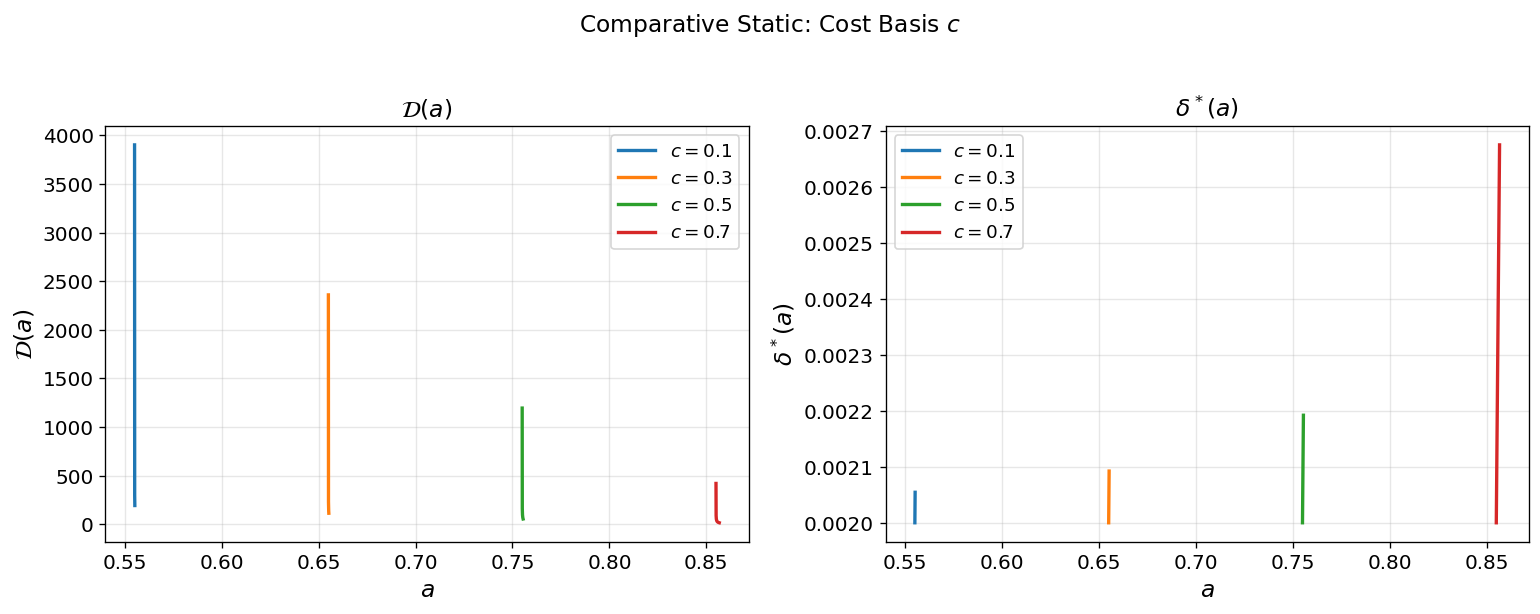

In [9]:
# === CS4: Cost basis c ===
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for c_val in [0.10, 0.30, 0.50, 0.70]:
    res = compute_lob(alpha, c_val, eta, N_LP, r_min, r_max)
    axes[0].plot(res['a'], res['D'], label=f'$c={c_val}$')
    axes[1].plot(res['a'], res['delta'], label=f'$c={c_val}$')
    print(f'c={c_val:.2f}: a_min={res["a_min"]:.3f}, width={res["book_width"]*1e4:.2f}x10^-4')
axes[0].set_title(r'$\mathcal{D}(a)$'); axes[0].set_ylabel(r'$\mathcal{D}(a)$')
axes[1].set_title(r'$\delta^*(a)$'); axes[1].set_ylabel(r'$\delta^*(a)$')
for ax in axes: ax.set_xlabel('$a$'); ax.legend(); ax.grid(True, alpha=0.3)
fig.suptitle('Comparative Static: Cost Basis $c$', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

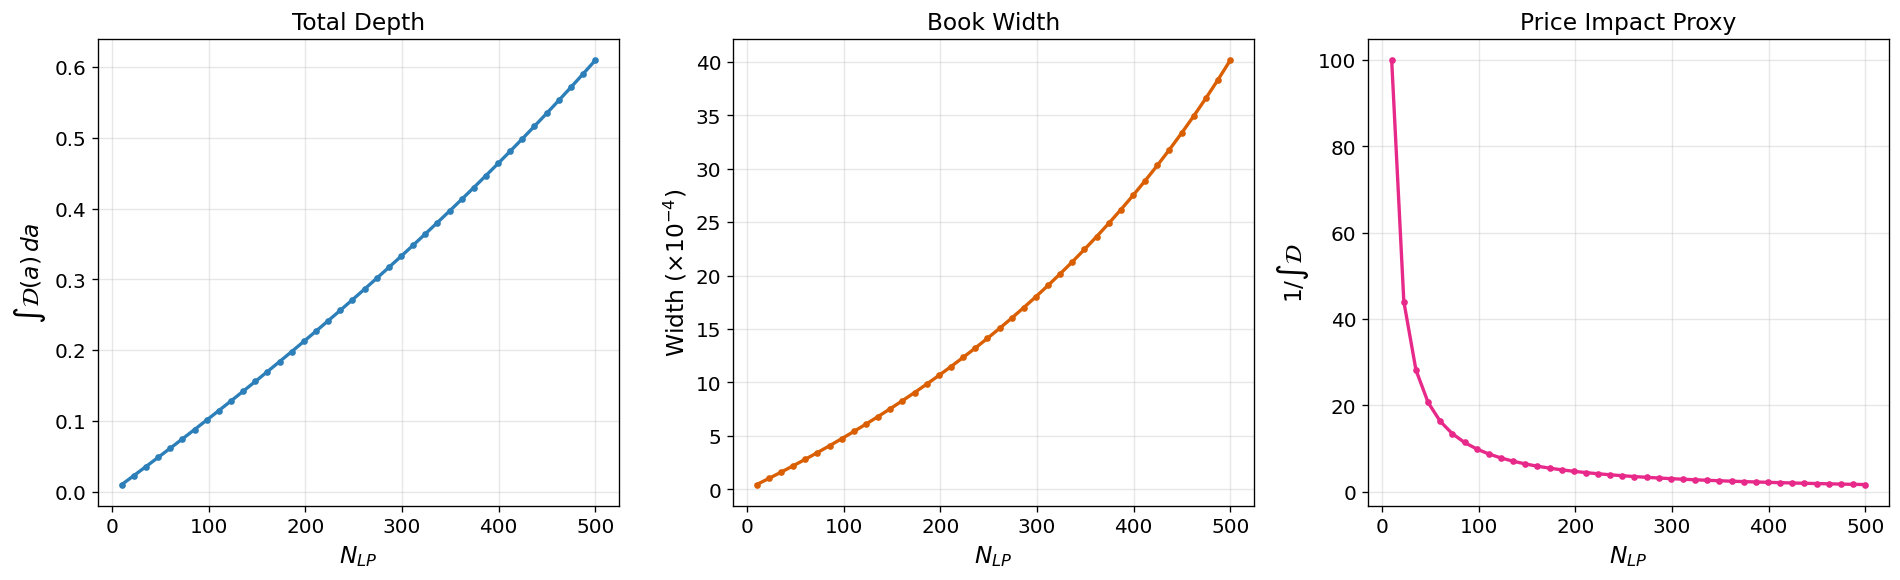

In [10]:
# === Total depth scaling with N_LP ===
N_range = np.linspace(10, 500, 40)
total_depths, book_widths = [], []
for N_val in N_range:
    res = compute_lob(alpha, c, eta, N_val, r_min, r_max)
    total_depths.append(res['total_depth'])
    book_widths.append(res['book_width'])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
ax1.plot(N_range, total_depths, 'o-', color='#2c7fb8', ms=3)
ax1.set_xlabel('$N_{LP}$'); ax1.set_ylabel(r'$\int \mathcal{D}(a)\, da$')
ax1.set_title('Total Depth'); ax1.grid(True, alpha=0.3)
ax2.plot(N_range, np.array(book_widths)*1e4, 'o-', color='#d95f02', ms=3)
ax2.set_xlabel('$N_{LP}$'); ax2.set_ylabel(r'Width ($\times 10^{-4}$)')
ax2.set_title('Book Width'); ax2.grid(True, alpha=0.3)
ax3.plot(N_range, 1.0/np.array(total_depths), 'o-', color='#e7298a', ms=3)
ax3.set_xlabel('$N_{LP}$'); ax3.set_ylabel(r'$1/\int\mathcal{D}$')
ax3.set_title('Price Impact Proxy'); ax3.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## §13. Extension: Pareto $G(r)$ — Power-Law LOB Shape

Under Pareto $G$: $g(r) = \beta\,r_{\min}^\beta\,r^{-(\beta+1)}$ for $r \ge r_{\min}$, $\beta > 1$.

The equilibrium ODE generalises: $g(r)$ is no longer constant, so the Bernoulli trick gives a different nonlinear term. We solve numerically.

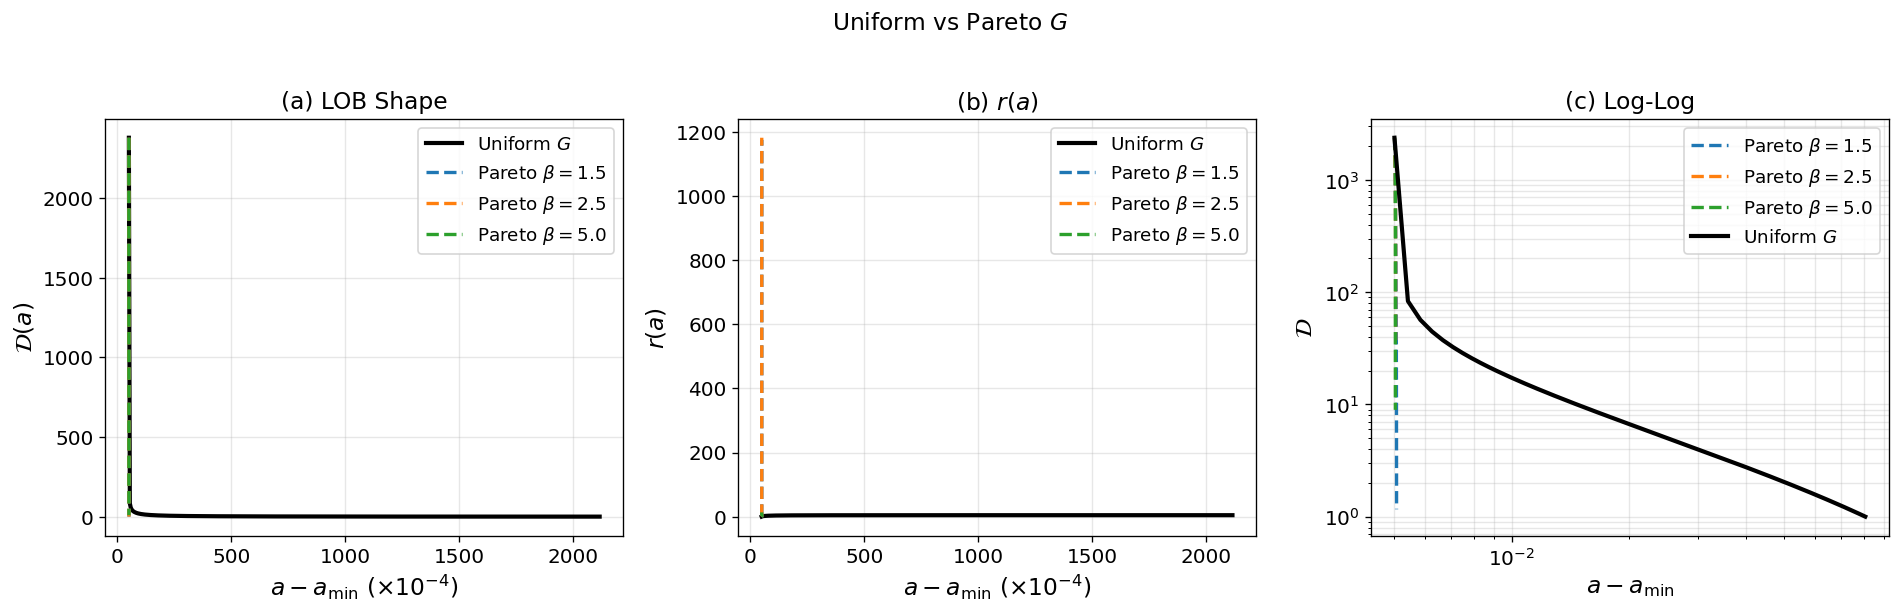

In [11]:
def solve_general_G(alpha_p, c_p, eta_p, N_LP_p, r_min_p, g_func,
                    eps_p=0.005, a_upper=0.98, n_pts=500):
    """Solve LOB ODE for general g(r) via solve_ivp."""
    am = (1 + c_p) / 2
    a0_p = am + eps_p
    D0 = float(H_func(a0_p, alpha_p, c_p)) / r_min_p
    def rhs(a, D_vec):
        D = D_vec[0]
        if D < 1e-15: return [0.0]
        Hv = float(H_func(float(a), alpha_p, c_p))
        Hp = float(H_prime(float(a), alpha_p, c_p))
        ds = float(delta_star(float(a), c_p, eta_p))
        if ds < 1e-15: return [0.0]
        g_val = g_func(Hv / D)
        if g_val < 1e-20: return [0.0]
        return [(Hp/Hv)*D - 2.0/(N_LP_p*ds*g_val*Hv)*D**3]
    def d_small(a, D): return D[0] - 0.1
    d_small.terminal = True; d_small.direction = -1
    sol = solve_ivp(rhs, [a0_p, a_upper], [D0], method='DOP853',
                    dense_output=True, rtol=1e-10, atol=1e-12,
                    max_step=(a_upper-a0_p)/200, events=d_small)
    ag = np.linspace(a0_p, sol.t[-1], n_pts)
    Dv = np.maximum(sol.sol(ag)[0], 0)
    return ag, Dv, np.where(Dv>0, H_func(ag,alpha_p,c_p)/Dv, np.inf)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
a_u, D_u, r_u = solve_general_G(alpha, c, eta, N_LP, r_min, lambda r: 1.0/Delta_r)
sig_u = a_u - a_min
axes[0].plot(sig_u*1e4, D_u, 'k-', lw=2.5, label='Uniform $G$')
axes[1].plot(sig_u*1e4, r_u, 'k-', lw=2.5, label='Uniform $G$')

for beta_val in [1.5, 2.5, 5.0]:
    g_par = lambda r, b=beta_val: b * r_min**b * r**(-(b+1))
    a_p, D_p, r_p = solve_general_G(alpha, c, eta, N_LP, r_min, g_par)
    sig_p = a_p - a_min
    axes[0].plot(sig_p*1e4, D_p, '--', lw=2, label=rf'Pareto $\beta={beta_val}$')
    axes[1].plot(sig_p*1e4, r_p, '--', lw=2, label=rf'Pareto $\beta={beta_val}$')
    mask = (D_p > 1) & (sig_p > 0)
    if np.sum(mask) > 5:
        axes[2].loglog(sig_p[mask], D_p[mask], '--', lw=2, label=rf'Pareto $\beta={beta_val}$')
mask_u = (D_u > 1) & (sig_u > 0)
if np.sum(mask_u) > 5:
    axes[2].loglog(sig_u[mask_u], D_u[mask_u], 'k-', lw=2.5, label='Uniform $G$')

axes[0].set_title('(a) LOB Shape'); axes[0].set_ylabel(r'$\mathcal{D}(a)$')
axes[1].set_title('(b) $r(a)$'); axes[1].set_ylabel('$r(a)$')
axes[2].set_title('(c) Log-Log'); axes[2].set_ylabel(r'$\mathcal{D}$')
for i, ax in enumerate(axes):
    ax.set_xlabel(r'$a - a_{\min}$ ($\times 10^{-4}$)' if i<2 else r'$a-a_{\min}$')
    ax.legend(); ax.grid(True, alpha=0.3, which='both')
fig.suptitle(r'Uniform vs Pareto $G$', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---

# Part IV: Price Dynamics and Informational Efficiency

## §14. Connecting Depth to Price Impact

The equilibrium $\mathcal{D}(a)$ determines the endogenous depth of the order book. We now connect this to a reduced-form price process to study **informational efficiency**.

### Fundamental Process

Let $\pi_t \in (0,1)$ be the true event probability, following a mean-reverting diffusion:
$$d\pi_t = \bar\alpha(\bar\pi - \pi_t)\,dt + \sigma_\pi\,dW_t.$$

### Order Flow

Buy/sell market orders arrive at Poisson rates sensitive to mispricing:
$$\lambda^{buy}_t = \lambda_0 + \lambda_1(\pi_t - p_t)^+, \qquad \lambda^{sell}_t = \lambda_0 + \lambda_1(p_t - \pi_t)^+.$$

### Price Impact

The YES price evolves via signed order flow with **depth-scaled impact**:
$$dp_t = \frac{\eta_{\text{imp}}}{D}\,dX_t, \qquad D = \int \mathcal{D}(a)\,da.$$

The key structural link:
$$\text{Impact} \propto \frac{1}{D}.$$

Deeper equilibrium liquidity $\Rightarrow$ smaller price impact $\Rightarrow$ tighter tracking of fundamentals $\Rightarrow$ greater informational efficiency.

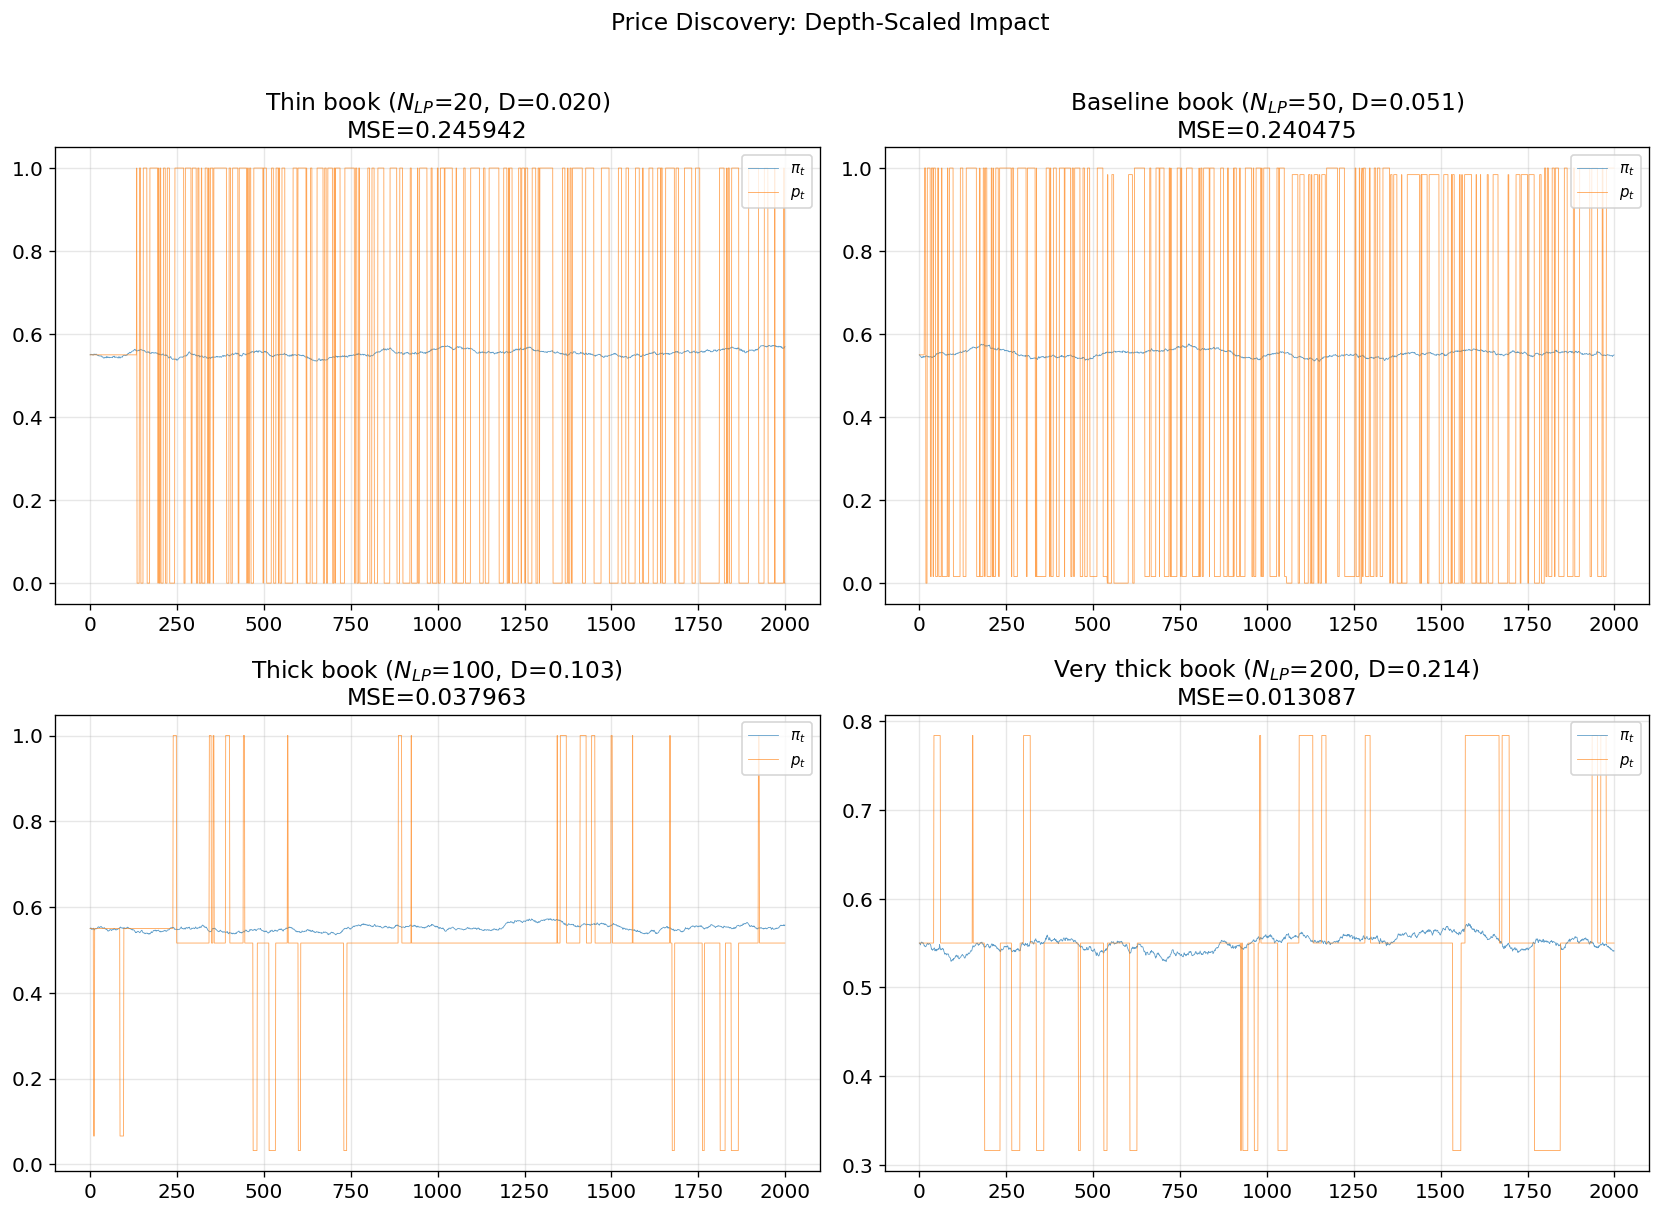

In [12]:
# === Price simulation using endogenous depth ===
rng = np.random.default_rng(42)

# Simulation parameters
T = 20000; dt = 0.01
pi_bar = 0.55; alpha_ou = 0.5; sigma_pi = 0.01
lambda0 = 0.5; lambda1 = 20.0
eta_imp = 0.05; eps_d = 1e-6

# Run for different depth levels
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (N_lp_val, label) in enumerate([(20, 'Thin'), (50, 'Baseline'), (100, 'Thick'), (200, 'Very thick')]):
    res = compute_lob(alpha, c, eta, N_lp_val, r_min, r_max)
    D_total = res['total_depth']
    impact = eta_imp / (D_total + eps_d)
    
    pi_path = np.zeros(T); p_path = np.zeros(T)
    pi_path[0] = pi_bar; p_path[0] = pi_bar
    
    for t in range(1, T):
        pi = pi_path[t-1] + alpha_ou*(pi_bar - pi_path[t-1])*dt + sigma_pi*np.sqrt(dt)*rng.standard_normal()
        pi_path[t] = np.clip(pi, 0, 1)
        mis = pi_path[t] - p_path[t-1]
        lam_buy  = max(lambda0 + lambda1*max(mis, 0), 0)
        lam_sell = max(lambda0 + lambda1*max(-mis, 0), 0)
        dX = rng.poisson(lam_buy*dt) - rng.poisson(lam_sell*dt)
        p_path[t] = np.clip(p_path[t-1] + impact*dX, 0, 1)
    
    mse = np.mean((p_path - pi_path)**2)
    ax = axes.flat[idx]
    ax.plot(pi_path[:2000], 'C0-', lw=0.5, alpha=0.7, label=r'$\pi_t$')
    ax.plot(p_path[:2000], 'C1-', lw=0.5, alpha=0.7, label='$p_t$')
    ax.set_title(f'{label} book ($N_{{LP}}$={N_lp_val}, D={D_total:.3f})\nMSE={mse:.6f}')
    ax.legend(loc='upper right', fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('Price Discovery: Depth-Scaled Impact', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

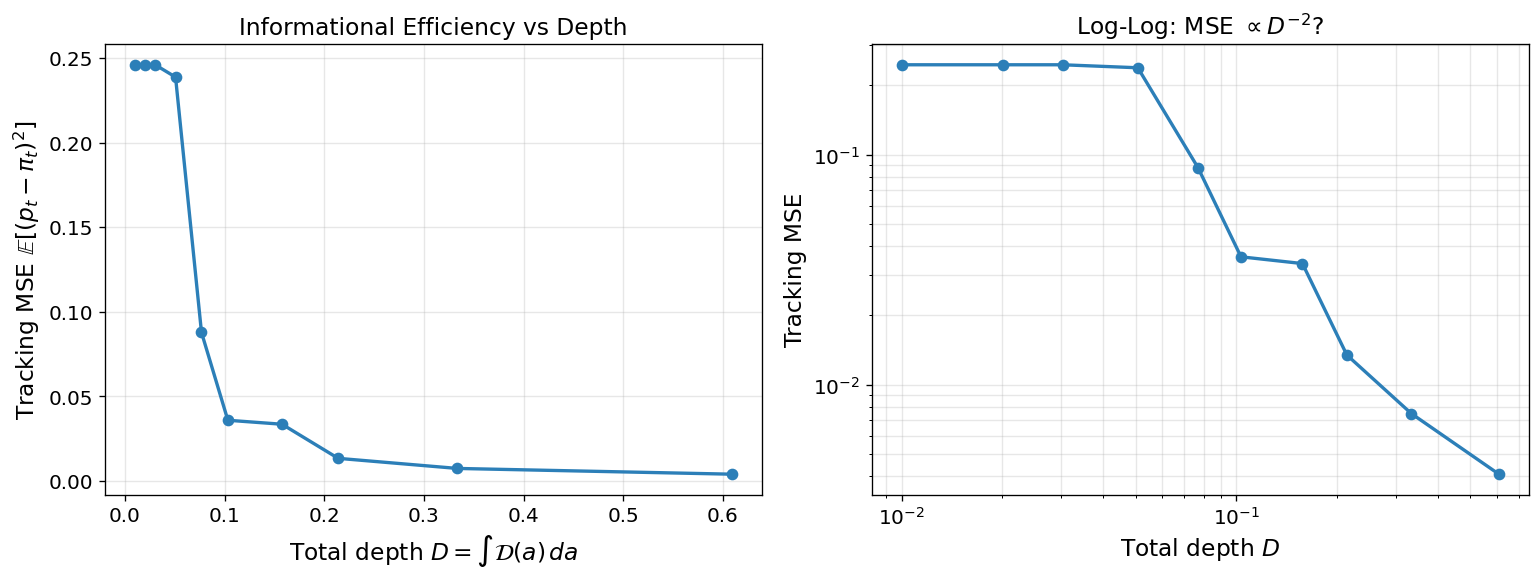

In [13]:
# === Tracking MSE vs depth (systematic) ===
N_vals = [10, 20, 30, 50, 75, 100, 150, 200, 300, 500]
mse_vals = []
depth_vals = []

for N_lp_val in N_vals:
    res = compute_lob(alpha, c, eta, N_lp_val, r_min, r_max)
    D_total = res['total_depth']
    depth_vals.append(D_total)
    impact = eta_imp / (D_total + eps_d)
    
    # Quick simulation
    rng2 = np.random.default_rng(123)
    pi_p = np.zeros(T); p_p = np.zeros(T)
    pi_p[0] = pi_bar; p_p[0] = pi_bar
    for t in range(1, T):
        pi = pi_p[t-1] + alpha_ou*(pi_bar - pi_p[t-1])*dt + sigma_pi*np.sqrt(dt)*rng2.standard_normal()
        pi_p[t] = np.clip(pi, 0, 1)
        mis = pi_p[t] - p_p[t-1]
        dX = rng2.poisson(max(lambda0+lambda1*max(mis,0),0)*dt) - rng2.poisson(max(lambda0+lambda1*max(-mis,0),0)*dt)
        p_p[t] = np.clip(p_p[t-1]+impact*dX, 0, 1)
    mse_vals.append(np.mean((p_p - pi_p)**2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(depth_vals, mse_vals, 'o-', color='#2c7fb8', ms=6)
ax1.set_xlabel(r'Total depth $D = \int\mathcal{D}(a)\,da$')
ax1.set_ylabel(r'Tracking MSE $\mathbb{E}[(p_t-\pi_t)^2]$')
ax1.set_title('Informational Efficiency vs Depth')
ax1.grid(True, alpha=0.3)

ax2.loglog(depth_vals, mse_vals, 'o-', color='#2c7fb8', ms=6)
ax2.set_xlabel(r'Total depth $D$'); ax2.set_ylabel('Tracking MSE')
ax2.set_title('Log-Log: MSE $\\propto D^{-2}$?')
ax2.grid(True, alpha=0.3, which='both')
plt.tight_layout(); plt.show()

---

# Part V: Summary and Next Steps

## §15. Summary of Results

### Analytical Contributions

1. **Bernoulli structure.** The equilibrium ODE for the LOB shape is a Bernoulli equation of order 3, exactly solvable via $w = \mathcal{D}^{-2}$. This gives a fully explicit closed-form solution under uniform $F$ and $G$.

2. **Book concentration.** Under uniform distributions, the LOB concentrates near $a_{\min} = (1+c)/2$ due to the $(a-a_{\min})^{-2}$ singularity in $H/\delta^*$. This is a structural prediction.

3. **$\mathcal{D}$-independence of $\delta^*$.** The optimal replenishment is independent of aggregate depth — the central decoupling that makes the model tractable.

4. **Pareto tails.** Heavy-tailed $G(r)$ generates power-law LOB shapes with wider ask-side support.

### Comparative Statics

| Parameter | Effect on $\mathcal{D}$ | Economic Mechanism |
|-----------|------------------------|--------------------|
| $N_{LP} \uparrow$ | Deeper, wider book | More LPs at every price level |
| $\alpha \uparrow$ | Deeper (through $H$) | More buyers $\Rightarrow$ higher fill value |
| $\eta \uparrow$ | Shallower book | Higher carrying cost $\Rightarrow$ smaller $\delta^*$ |
| $c \uparrow$ | Book shifts right, thins | Higher cost $\Rightarrow$ wider spreads needed |
| $r_{\max} \uparrow$ | Wider support | More impatient types fill out the tail |

### Connection to Informational Efficiency

The endogenous depth $D = \int \mathcal{D}(a)\,da$ determines price impact $\propto 1/D$. Simulations confirm that deeper books yield lower tracking MSE — the MFG equilibrium governs informational efficiency through the liquidity channel.

---

## §16. Next Steps

### Analytical
1. **Pareto closed-form.** Derive the Bernoulli ODE solution under Pareto $g(r)$ — the integrating factor is $H(a)^2$ times a power of the Pareto kernel.
2. **Non-uniform $F$.** Beta distributions $F(a) = B(a; p, q)$ give more realistic buyer belief heterogeneity. The ODE structure is preserved; the antiderivative changes.
3. **Bid side.** Extend to symmetric bid-side depth and derive the full spread $s(a) = a_{ask} - a_{bid}$.

### Empirical
4. **Polymarket calibration.** Fit $G(r)$ to observed LOB depth snapshots from Polymarket BTC contracts. The monotone map $a \mapsto r(a)$ means the empirical $\mathcal{D}(a)$ directly identifies $G$.
5. **Price impact estimation.** Test the model prediction $\text{impact} \propto 1/D$ against trade-level data.

### Model Extensions
6. **Dynamic depth.** The current model is stationary; extend to time-varying $\mathcal{D}(a, t)$ near event resolution.
7. **Strategic interaction.** Relax the mean-field assumption for small $N_{LP}$ (oligopoly regime).
8. **Welfare.** Compute total surplus and optimal market design (fee structure, tick size).

### Relationship to Previous Work

The rank-based MFG model (Ma–Noh framework, implemented in `MFG_ClosedForm-V2.ipynb`) computes the liquidity distribution $\mu^*$ via HJB–KFE fixed-point iteration on a rank grid. The Bertrand model developed here is complementary: it gives a **closed-form** LOB shape by exploiting LP heterogeneity in discount rates rather than rank-based dynamics. The two approaches can be unified by embedding the Bertrand equilibrium as the outer layer of the rank-based MFG — the rank-based model governs within-price dynamics while the Bertrand structure governs the cross-price allocation.